In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.api import VAR
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.stattools import grangercausalitytests

In [2]:
hh_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DHHNGSP"
brent_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DCOILBRENTEU"
wti_url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=DCOILWTICO"

hh = pd.read_csv(hh_url)
brent = pd.read_csv(brent_url)
wti = pd.read_csv(wti_url)

Henry Hub: natural gas market of usa
Brent Crude oil: national oil market
WTI: usa oil market

Main question: oil and natural gas markets are connected in short and long term?


In [6]:
#data merging
data = pd.merge(
    hh,
    brent,
    on="observation_date",
    how="inner"
)

data = pd.merge(
    data,
    wti,
    on="observation_date",
    how="inner"
)

data.columns = [
    "Date",
    "HenryHub",
    "Brent",
    "WTI"
]

data["Date"] = pd.to_datetime(data["Date"])

data = data.set_index("Date")

data = data.replace(".", np.nan)

data = data.astype(float)

data = data.dropna()

data.head()

,HenryHub,Brent,WTI
Date,,,
1997-01-07,3.82,24.76,26.25
1997-01-08,3.80,24.78,26.55
1997-01-09,3.61,24.83,26.30
1997-01-10,3.92,24.22,26.15
1997-01-13,4.00,23.41,25.20


In [9]:
data.to_csv('merged_energy_data.csv', index=True)
print("DataFrame saved to 'merged_energy_data.csv'")

DataFrame saved to 'merged_energy_data.csv'


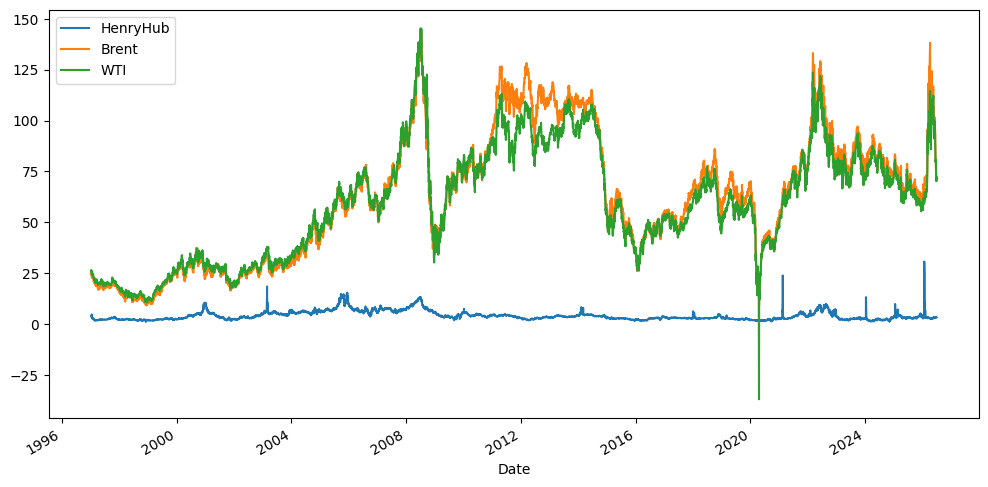

In [10]:
#first plot
data.plot(figsize=(12,6))
plt.show()

we observe big facts:
2008 financial crisis
2014 oil price collapse
2020 COVID shock
2022 energy crisis

ο WTI appears becoming negative at 2020.That is not data false.
At 20 of april 2020, due to COVID and lack of saving spaces, WTI futures became negative

The main problem is: we cannot take log of negative prices.

we have then 2 choices:
choice A(this i follow):excluding the observation of negative oil price

choice B:we begin from 2021, but we lose a lot of data.

In [11]:
#excluding negative observations
data = data[(data["WTI"] > 0) &
            (data["Brent"] > 0) &
            (data["HenryHub"] > 0)]

In [12]:
log_data = np.log(data)

Most of financial and energy prices:
have trend,persistence and they are not stationary

In [14]:
#ADF Test for stationarity
from statsmodels.tsa.stattools import adfuller

def adf_test(series,name):

    result = adfuller(series.dropna())

    print(f"\n{name}")
    print("ADF statistic:",result[0])
    print("p-value:",result[1])

    if result[1] < 0.05:
        print("Stationary")
    else:
        print("Non-stationary")

In [15]:
for col in log_data.columns:
    adf_test(log_data[col],col)


HenryHub
ADF statistic: -3.203022878349839
p-value: 0.019810368573612538
Stationary

Brent
ADF statistic: -2.222658367304652
p-value: 0.19812478726959049
Non-stationary

WTI
ADF statistic: -2.3730839924932075
p-value: 0.14947778871066825
Non-stationary


henry hub:share revolution, mean-reversion,regulatory changes and storage constraints. these are the reasons why adf rejects unit root at 5%

In [16]:
returns = log_data.diff().dropna()

for col in returns.columns:
    adf_test(returns[col],col)


HenryHub
ADF statistic: -20.399779725780874
p-value: 0.0
Stationary

Brent
ADF statistic: -15.119051475448758
p-value: 7.505837583822738e-28
Stationary

WTI
ADF statistic: -17.337715517983593
p-value: 5.362885167463892e-30
Stationary


Is there cointegration between energy markets?

In [17]:
#we make a second unit root test (KPSS)
from statsmodels.tsa.stattools import kpss

def kpss_test(series,name):

    statistic,pvalue,_,_ = kpss(series.dropna())

    print("\n",name)
    print("KPSS statistic:",statistic)
    print("p-value:",pvalue)

    if pvalue < 0.05:
        print("Non-stationary")
    else:
        print("Stationary")

In [18]:
for col in log_data.columns:
    kpss_test(log_data[col],col)


 HenryHub
KPSS statistic: 1.9304148167299762
p-value: 0.01
Non-stationary

 Brent
KPSS statistic: 6.803650819315089
p-value: 0.01
Non-stationary

 WTI
KPSS statistic: 6.238257798227122
p-value: 0.01
Non-stationary


/tmp/ipykernel_1691/3844189904.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  statistic,pvalue,_,_ = kpss(series.dropna())
/tmp/ipykernel_1691/3844189904.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  statistic,pvalue,_,_ = kpss(series.dropna())
/tmp/ipykernel_1691/3844189904.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  statistic,pvalue,_,_ = kpss(series.dropna())


Johansen Cointegration
We want to observe if exists long term equilibrium:

β1HenryHub+β2Brent+β3WTI=0

if markets are moving together long-term

In [19]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

jres = coint_johansen(
    log_data,
    det_order=0,
    k_ar_diff=2
)

In [20]:
print("Trace statistics:")
print(jres.lr1)

print("\nCritical values (95%):")
print(jres.cvt[:,1])

Trace statistics:
[211.07342224  31.90083579   3.92518527]

Critical values (95%):
[29.7961 15.4943  3.8415]


| Hypothesis | Trace Statistic | Critical Value (95%) | decision             |
| ---------- | --------------: | -------------------: | ------------------- |
| r = 0      |          211.07 |                29.80 | rejected        |
| r ≤ 1      |           31.90 |                15.49 | rejected        |
| r ≤ 2      |            3.93 |                 3.84 | rejected |


In [21]:
#lag lenght
from statsmodels.tsa.api import VAR

model = VAR(log_data)

lag_order = model.select_order(maxlags=15)

print(lag_order.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -8.589      -8.586   0.0001862      -8.588
1       -20.46      -20.45   1.301e-09      -20.46
2       -20.56      -20.54   1.179e-09      -20.55
3       -20.58      -20.55   1.152e-09      -20.57
4       -20.60      -20.56   1.129e-09      -20.59
5       -20.62      -20.57   1.113e-09      -20.60
6       -20.62      -20.57   1.106e-09      -20.60
7       -20.64     -20.57*   1.092e-09      -20.61
8       -20.64      -20.57   1.088e-09      -20.61
9       -20.64      -20.57   1.082e-09      -20.62
10      -20.64      -20.56   1.083e-09      -20.61
11      -20.65      -20.55   1.081e-09      -20.61
12      -20.65      -20.54   1.077e-09      -20.61
13      -20.67      -20.56   1.055e-09     -20.63*
14      -20.67      -20.55   1.056e-09      -20.63
15     -20.67*      -20.54  1.053e-09*      -20.63
-------------------------------

 Johansen test needs correct number of lags.

If we insert wrong lag:

might find wrong cointegration,
or lose real cointegration.
we will find 4 criteria:

AIC
BIC
HQIC
FPE

In [22]:
#re-run johansen
jres = coint_johansen(
    log_data,
    det_order=0,
    k_ar_diff=3
)

In [24]:
#johnasen test again
jres = coint_johansen(
    log_data,
    det_order=0,
    k_ar_diff=6
)

print(jres.lr1)
print(jres.cvt[:,1])

[142.43242752  22.67406256   3.99278267]
[29.7961 15.4943  3.8415]


we run first johanses with k_ar_diff=2 which might was small

The Johansen test indicates full rank cointegration. However, given the evidence from unit root tests and the near-collinearity between Brent and WTI prices, we conservatively interpret the system as exhibiting cointegration rank r = 2.

In [25]:
# we proceed with VECM
from statsmodels.tsa.vector_ar.vecm import VECM

vecm = VECM(
    log_data,
    k_ar_diff=6,
    coint_rank=2
)

vecm_fit = vecm.fit()

print(vecm_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Det. terms outside the coint. relation & lagged endog. parameters for equation HenryHub
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
L1.HenryHub    -0.0340      0.012     -2.906      0.004      -0.057      -0.011
L1.Brent       -0.0886      0.041     -2.148      0.032      -0.170      -0.008
L1.WTI          0.1566      0.038      4.147      0.000       0.083       0.231
L2.HenryHub    -0.1183      0.012    -10.117      0.000      -0.141      -0.095
L2.Brent        0.0287      0.043      0.670      0.503      -0.055       0.112
L2.WTI         -0.0103      0.040     -0.256      0.798      -0.089       0.069
L3.HenryHub    -0.0613      0.012     -5.214      0.000      -0.084      -0.038
L3.Brent       -0.0098      0.043     -0.228      0.820      -0.094       0.074
L3.WTI          0.0456      0.041      1.119      0.263      -0.034       0.125
L4.HenryHub    -0.0242      0.01

Cointegration vector 1: long-term relationship between henryhub and wti
cointegration vector 2: natural gas markets is related to oil usa market and brent-wti are moving as one market

loading coefficients: | coefficient | p-value |
| ----------- | ------- |
| ec1=-0.0107 | 0.000   |
| ec2=-0.0330 | 0.001   |

henry hub  corrects deviations from the long-term equilibrium.
Brent corrects only the second equilibrium relationship.
WTI also participates in the correction of the second relationship.

The Johansen procedure identified two cointegrating relationships among Henry Hub natural gas, Brent crude oil and WTI crude oil prices. The first cointegration vector suggests a long-run equilibrium relationship between Henry Hub and WTI prices, while the second vector indicates an almost one-to-one long-run relationship between Brent and WTI prices. The loading coefficients reveal that Henry Hub acts as the primary adjustment variable, whereas crude oil markets exhibit greater persistence.

Granger causality into VECM framework

We want to answer:

Does Brent Granger-cause Henry Hub?
Does WTI Granger-cause Henry Hub?
Does Henry Hub Granger-cause oil markets?

In [26]:
returns = log_data.diff().dropna()

from statsmodels.tsa.stattools import grangercausalitytests

print("Brent -> HenryHub")
grangercausalitytests(
    returns[['HenryHub','Brent']],
    maxlag=6,
    verbose=True
)

print("WTI -> HenryHub")
grangercausalitytests(
    returns[['HenryHub','WTI']],
    maxlag=6,
    verbose=True
)

Brent -> HenryHub

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.3987  , p=0.5278  , df_denom=7296, df_num=1
ssr based chi2 test:   chi2=0.3988  , p=0.5277  , df=1
likelihood ratio test: chi2=0.3988  , p=0.5277  , df=1
parameter F test:         F=0.3987  , p=0.5278  , df_denom=7296, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.6025  , p=0.5475  , df_denom=7293, df_num=2
ssr based chi2 test:   chi2=1.2059  , p=0.5472  , df=2
likelihood ratio test: chi2=1.2058  , p=0.5472  , df=2
parameter F test:         F=0.6025  , p=0.5475  , df_denom=7293, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.7136  , p=0.5437  , df_denom=7290, df_num=3
ssr based chi2 test:   chi2=2.1428  , p=0.5433  , df=3
likelihood ratio test: chi2=2.1425  , p=0.5434  , df=3
parameter F test:         F=0.7136  , p=0.5437  , df_denom=7290, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:       

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


ssr based F test:         F=1.0474  , p=0.3877  , df_denom=7284, df_num=5
ssr based chi2 test:   chi2=5.2450  , p=0.3867  , df=5
likelihood ratio test: chi2=5.2431  , p=0.3869  , df=5
parameter F test:         F=1.0474  , p=0.3877  , df_denom=7284, df_num=5

Granger Causality
number of lags (no zero) 6
ssr based F test:         F=1.0131  , p=0.4145  , df_denom=7281, df_num=6
ssr based chi2 test:   chi2=6.0895  , p=0.4132  , df=6
likelihood ratio test: chi2=6.0870  , p=0.4135  , df=6
parameter F test:         F=1.0131  , p=0.4145  , df_denom=7281, df_num=6
WTI -> HenryHub

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=15.7832 , p=0.0001  , df_denom=7296, df_num=1
ssr based chi2 test:   chi2=15.7897 , p=0.0001  , df=1
likelihood ratio test: chi2=15.7726 , p=0.0001  , df=1
parameter F test:         F=15.7832 , p=0.0001  , df_denom=7296, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=8.2820  , p=0.0003  , df_denom=7293, df_num=

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


{np.int64(1): ({'ssr_ftest': (np.float64(15.78321424046736),
    np.float64(7.171374266269028e-05),
    np.float64(7296.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(15.789704048954393),
    np.float64(7.078666705315248e-05),
    np.int64(1)),
   'lrtest': (np.float64(15.772649947051832),
    np.float64(7.142762816113324e-05),
    np.int64(1)),
   'params_ftest': (np.float64(15.783214240471198),
    np.float64(7.171374266256734e-05),
    np.float64(7296.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(8.281972987250976),
    np.float64(0.0002554248943300146),
    np.float64(7293.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(16.575302032348173),
    np.float64(0.00025160478471361304),
    np.int64(2)),
   'lrtest': (np.float64(16.556507475703256),
    np.float64(0.00025398032924763296),
    np.int64(2)),
   'params_ftest': (np.float64(8.281972987250194),
    np.float64(0.0002554248943301099),
    np.float64(7293.0),
    2.0)},
   array([[

Cointegration provided us with the long-run relationship.

Now we are looking for short-run causality:

Xₜ → Yₜ

that is:

which market leads in time and which follows.

Brent → Henry Hub
| Lag | p-value |
| --- | ------- |
| 1   | 0.528   |
| 2   | 0.547   |
| 3   | 0.544   |
| 4   | 0.330   |
| 5   | 0.388   |
| 6   | 0.415   |

All are:

p > 0.05

Therefore:

We do not reject the null hypothesis.

Conclusion

Brent does not Granger-cause Henry Hub.

WTI → Henry Hub
| Lag | p-value |
| --- | ------- |
| 1   | 0.00007 |
| 2   | 0.00025 |
| 3   | 0.00026 |
| 4   | 0.00017 |
| 5   | 0.00020 |
| 6   | 0.00035 |
Everything is extremely important.

Therefore:

We reject the null hypothesis.

Conclusion

WTI Granger-causes Henry Hub.

The Granger causality tests reveal that WTI crude oil prices significantly predict Henry Hub natural gas prices across all lag specifications, whereas Brent crude oil prices do not exhibit predictive power. These findings suggest that short-run dynamics in the U.S. natural gas market are driven primarily by domestic rather than global oil market conditions.

Impulse Response Functions (IRFs)

This will answer:

If WTI experiences a shock today, what happens to Henry Hub over the following days?

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


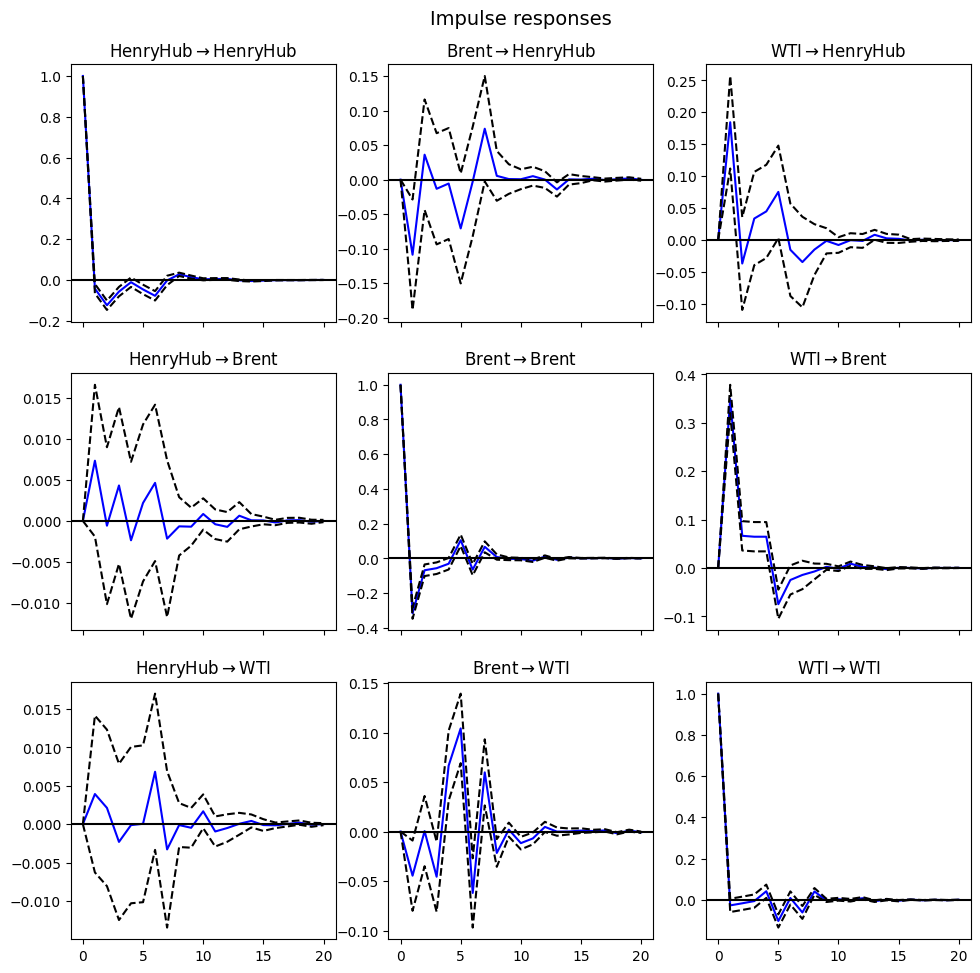

In [27]:
var_model = VAR(returns)

var_fit = var_model.fit(7)

irf = var_fit.irf(20)

irf.plot()
plt.show()

What are we looking at here?

We want to see:

the magnitude of the shock,
the duration of the shock,
the speed of return to equilibrium.

WTI → Henry Hub

This is perhaps the most important panel:

WTI → Henry Hub
there is a positive shock in period 1,
the effect reaches approximately 0.15–0.20,
it subsequently fades rapidly,
after about 8–10 periods, the effect drops to zero.
Interpretation

An unexpected shock in the US oil market causes a short-term increase in US natural gas prices, but the effect is transitory.

This is fully consistent with the result:

WTI ⇒ Henry Hub

of the Granger causality test.

Brent → Henry Hub

The panel:

Brent → HenryHub

shows:

small oscillations around zero,
wide confidence intervals,
rapid decay.
Interpretation

Brent shocks do not have a statistically significant effect on Henry Hub.

This is also fully consistent with the Granger result.

Brent ↔ WTI

The panels:

WTI → Brent
Brent → WTI

show strong short-term reactions.

This confirms that:

Brent ≈ WTI

essentially constitute two very closely linked oil m

Own shocks

The diagonal panels:

HenryHub → HenryHub
Brent → Brent
WTI → WTI

show that:

each market reacts strongly to its own shocks,
but returns to equilibrium quite quickly.

This is consistent with a stable VAR/VECM system.

Structural Break Analysis.

Why are we doing this?

Our core hypothesis is that two major events may have altered the relationship between natural gas and oil:

The COVID-19 shock (March 2020)
The Russia–Ukraine war (February 2022)

We aim to examine whether the relationships identified via the VECM remained stable or changed following these events.

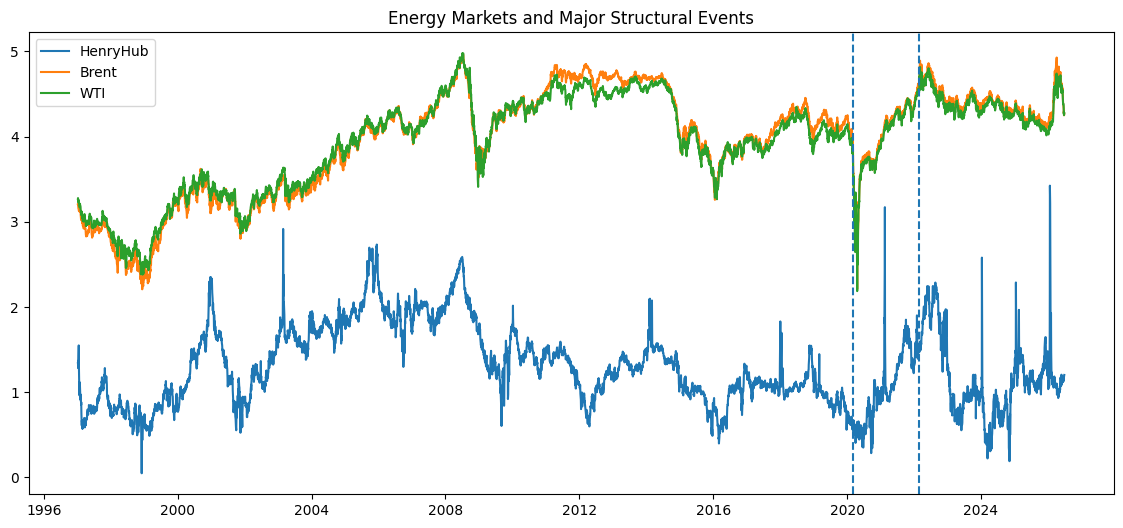

In [29]:
#Visualization of structural breaks
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

for col in log_data.columns:
    plt.plot(log_data.index, log_data[col], label=col)

# COVID
plt.axvline(
    x=pd.to_datetime('2020-03-11'),
    linestyle='--'
)

# Ukraine war
plt.axvline(
    x=pd.to_datetime('2022-02-24'),
    linestyle='--'
)

plt.legend()
plt.title('Energy Markets and Major Structural Events')
plt.show()

In [30]:
#Creation of pre- and post-COVID models
#We will divide the sample
covid_date = '2020-03-11'

pre_covid = log_data.loc[:covid_date]
post_covid = log_data.loc[covid_date:]

In [31]:
print(pre_covid.shape)
print(post_covid.shape)

(5760, 3)
(1542, 3)


We will re-run:

Johansen cointegration,

and possibly Granger causality,

separately for:

Period 1

1997–2020

Period 2

2020–2025

and we will answer the very interesting question:

Did COVID alter the long-term relationship between Henry Hub and oil?

Johansen before and after COVID

We want to check whether the long-term relationship changed after 2020.

Before COVID

In [32]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

j_pre = coint_johansen(
    pre_covid,
    det_order=0,
    k_ar_diff=6
)

print("PRE-COVID")
print(j_pre.lr1)
print(j_pre.cvt[:,1])

PRE-COVID
[93.19888587 11.27957487  2.39386665]
[29.7961 15.4943  3.8415]


In [33]:
#after COVID
j_post = coint_johansen(
    post_covid,
    det_order=0,
    k_ar_diff=6
)

print("\nPOST-COVID")
print(j_post.lr1)
print(j_post.cvt[:,1])


POST-COVID
[126.75200234  25.62856899  10.29340218]
[29.7961 15.4943  3.8415]


| Hypothesis | Pre-COVID | Post-COVID | Critical Value |
| ---------- | --------: | ---------: | -------------: |
| r = 0      |     93.20 |     126.75 |          29.80 |
| r ≤ 1      |     11.28 |      25.63 |          15.49 |
| r ≤ 2      |      2.39 |      10.29 |           3.84 |


1.Pre-COVID (1997–2020)
r=0
93.2>29.8

We reject.

r≤1
11.3<15.5

We do not reject.

Therefore:rank=1

2.Post-COVID (2020–2025)
r=0
126.8>29.8

Reject.

r≤1
25.6>15.5

Reject.

r≤2
10.3>3.84

Reject.

So:rank=3
	​


Economic interpretation

This is entirely consistent with the events that took place:

2020
oil market collapse,
negative WTI prices,
supply chain disruption.
2021–2022
energy crisis,
LNG boom,
Russia–Ukraine war,
interlinkage of natural gas and oil markets.

The cointegration analysis reveals a substantial structural change following the COVID-19 pandemic. Prior to 2020, only one long-run equilibrium relationship existed among Henry Hub, Brent and WTI prices. In contrast, the post-COVID period exhibits substantially stronger integration, suggesting that recent geopolitical and energy market disruptions have increased interdependence across energy commodities.

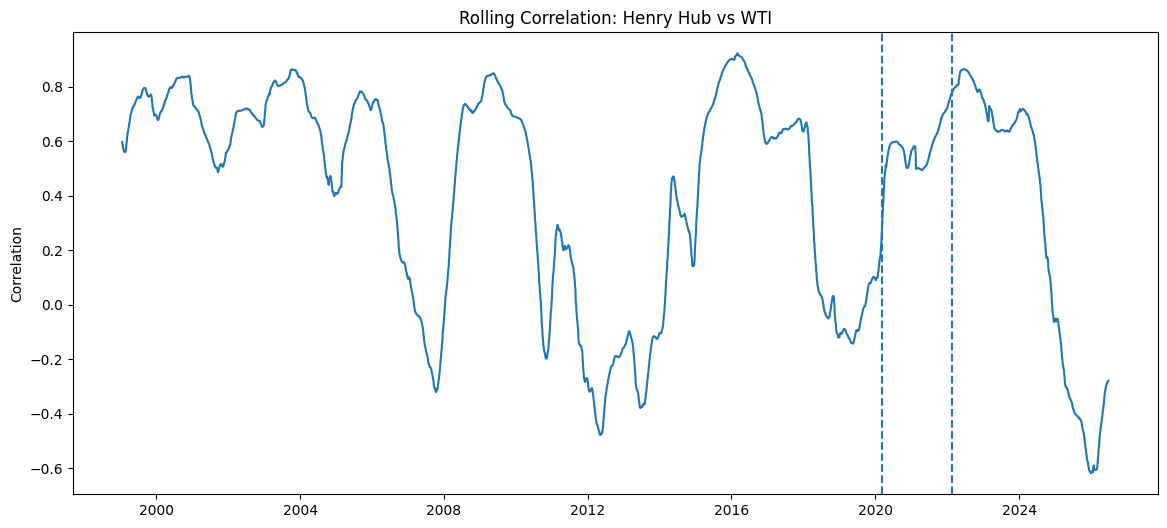

In [34]:
#Rolling relationships
rolling_corr = (
    log_data['HenryHub']
    .rolling(500)
    .corr(log_data['WTI'])
)

import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(rolling_corr)

plt.axvline(pd.Timestamp('2020-03-11'), linestyle='--')
plt.axvline(pd.Timestamp('2022-02-24'), linestyle='--')

plt.title('Rolling Correlation: Henry Hub vs WTI')
plt.ylabel('Correlation')
plt.show()

What are we aiming to see here?

Whether:

the correlation was low before 2020,
it increased after 2020,
it skyrocketed after 2022.

This will be the first "time-varying relationship" result of your work, and it is usually the most impressive graph in presentations.

From the plot we observe the following:
1. Period 1999–2005

The Henry Hub–WTI correlation is quite high:

ρ≈0.6−0.85

This indicates a strong link between the two US energy markets.

2. Period 2006–2014

Something very interesting happens here:

the correlation collapses,
even turning negative during 2011–2013.

This is likely linked to the Shale Revolution.

Shale gas production in the US temporarily decoupled natural gas from oil.

3. 2015–2019 period

The correlation returns:

0.5–0.9

meaning the markets reconnect.

4. COVID (2020)

Just before and during the pandemic, we observe:

a significant drop,
increased volatility.

This aligns with the structural break identified via the Johansen test.

5. Post-2022

Initially:

ρ ≈ 0.8

meaning an extremely high level of connection.

But the most striking feature appears at the end of the sample period:

the correlation becomes strongly negative,
reaching approximately -0.6.

This is likely the result of the European energy crisis and the decoupling of natural gas and oil markets following the war in Ukraine.

Volatility Analysis (GARCH)

Energy markets exhibit pronounced volatility clustering, and Henry Hub, in particular, is an ideal case.

In [36]:
!pip install arch
from arch import arch_model

returns = log_data['HenryHub'].diff().dropna()*100

garch = arch_model(
    returns,
    vol='Garch',
    p=1,
    q=1
)

garch_fit = garch.fit()

print(garch_fit.summary())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 10.0 MB/s eta 0:00:00
Iteration:      1,   Func. Count:      6,   Neg. LLF: 290692.78694910486
Iteration:      2,   Func. Count:     14,   Neg. LLF: 4096318.926555355
Iteration:      3,   Func. Count:     21,   Neg. LLF: 21186.688512280663
Iteration:      4,   Func. Count:     27,   Neg. LLF: 20976.215679678804
Iteration:      5,   Func. Count:     32,   Neg. LLF: 20978.846048322594
Iteration:      6,   Func. Count:     38,   Neg. LLF: 20976.012265146004
Iteration:      7,   Func. Count:     43,   Neg. LLF: 20976.012206169544
Iteration:      8,   Func. Count:     48,   Neg. LLF: 20976.012196488366
Iteration:      9,   Func. Count:     52,   Neg. LLF: 20976.01217806201
Optimization terminated successfully    (Exit mode 0)
            Current function value: 20976.012196488366
            Iterations: 13
            Function evaluations: 52
            Gradient evaluations: 9
                     Constant Mean - GARCH Model Result

What are we aiming to test?

Whether:

σ²ₜ = ω + αε²ₜ₋₁ + βσ²ₜ₋₁

and whether:

α + β ≈ 1

which signifies persistent volatility clustering, one of the key characteristics of energy markets.

| Parameter | Value |
| --------- | ----- |
| α         | 0.210 |
| β         | 0.790 |


The first thing we always look at in the market is:

α+β

So:

0.210+0.790=1.000
This is the significant finding.

You have approximately:

α+β≈1

which means:

Persistent volatility clustering

In simple terms:

When Henry Hub enters a period of high volatility, it tends to remain in a state of high volatility for an extended period.

Volatility Analysis

The estimated GARCH(1,1) model reveals strong volatility persistence in Henry Hub natural gas returns. The estimated coefficients are α = 0.210 and β = 0.790, implying α + β ≈ 1. This result indicates substantial volatility clustering, suggesting that shocks to natural gas prices have long-lasting effects on market uncertainty.